# Tipping Points in Psychopathology 

In [1]:
# imports
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import animation
from tqdm import tqdm
#import powerlaw

## Ising Model

In [2]:
class IsingSimulation:

    def __init__(self, network, initial_state=None, H=1.0, J=1.0, T=2.26, length=10_000, warmup=1000):
        """
        Initialises the Ising model simulation

        Parameters:

        network: the network of nodes, where each node is a symptom
        initial_state: the initial state of the system (patient's mind). If nothing is provided, the state will be random

        H: the external field applied on the system - stress
        J: the coupling - how much neighbouring emotions want to align
        T: the temperature/ noise - how strong are random swings from one state to the other
        
        length: the amount of time steps to simulate
        warmup: The amount of steps to take before starting the simulation, to allow the system to settle down
        """

        # The network of nodes, that is the brain of the patient
        self.network = network

        # Transform the network into a numpy array for easier computations down the line
        self.adj_matrix = nx.to_numpy_array(self.network)
        
        # The size of the system N
        self.num_nodes = self.adj_matrix.shape[0]
        
        # The physics that govern the system
        self.H = H # The external stressor
        self.T = T # The noise in the system

        # compute the coupling between emotions so that the default behaviour is a patient with a rigid brain
        # whose emotions are strongly coupled
        # This allows to display a sharp phase transition from healthy to depressed if the external stress is high
        if J is None:

            # degrees of all nodes
            degrees = np.sum(self.adj_matrix, axis=1)
            # largest degree
            max_degree = np.max(degrees)
            
            # we want the nodes with largest degrees to be stable against the noise T
            factor = 2
            self.J = (self.T  / max_degree) * factor
            
            print(f"computed J: {self.J:.4f}")
        
        else:
        
            self.J = J

        # The initial state of the system
        # If an initial state is not provided we should assign randomly a value in {-1, 1} to each node
        # However if we provide an initial state, the warmup is prohibited since we would be deviating from that initial state
        if initial_state is None:

            self.warmup = warmup
            self.current_state = np.random.choice([-1, 1], size=self.num_nodes)
        
        else:
        
            self.warmup = 0
            self.current_state = np.array(initial_state)

        # The time settings
        self.length = length # the number of time steps to perform

        # The records of the evolution of the simulation
        # Storing the state of each node for all time steps
        self.history = np.zeros((self.length, self.num_nodes), dtype=np.int8)

        # Store the state of each node during the warmup period (for covariance calculations)
        self.warmup_states = np.zeros((self.warmup, self.num_nodes), dtype=np.int8)

        # storing the average mood - order parameter, m, at each time step
        self.order_history = np.zeros(self.length)

        # Storing the external field/Stress applied on the system at each point in time
        self.h_history = np.zeros(self.length)

        # Storing the covariance matrices to compute the eigenvalues later
        self.cov_matrices = None


    def step(self):
        """
        Performs one Monte Carlo step 
        We attempt to flip randomly selected nodes one by one.
        """

        # Loop N times so every node has the chance of being update per time step
        for _ in range(self.num_nodes):

            # Pick a random node
            node_idx = np.random.randint(0, self.num_nodes)
            
            # Identify the current state of that node
            s = self.current_state[node_idx]
            
            # The influence from neighbors
            # Row of Adjacency matrix @ State of all the noodes
            neighbor_sum = np.dot(self.adj_matrix[node_idx], self.current_state)
            
            # The total force applied on this node as per the Ising model
            # Force = (Coupling * Neighbors) + External field
            total_force = (self.J * neighbor_sum) + self.H
            
            # The Energy cost to flip the current node
            delta_E = 2 * s * total_force
            
            # The metropolis decision
            # if the energy decreases then we flip the node immediately
            # if the energy increases then we still have a prob of flipping due to random noise
            if delta_E < 0:

                self.current_state[node_idx] *= -1

            # Flip with probability P = exp(-dE/T)
            elif np.random.random() < np.exp(-delta_E / self.T):
                
                self.current_state[node_idx] *= -1



    def run(self, delta_H=None):
        """
        Runs the model for the specified length of time in the init
        If delta_H is specified, the stress moves up or down at each step
        """
        # Save the original H so we can reset it later
        original_H = self.H
        
        # Warmup - Settling down from pure random noise
        # Run the physics, but we dont record the data
        for i in range(self.warmup):
            self.step()
            self.warmup_states[i] = self.current_state.copy()
        
        
        # Record the state right after warmup as t=0
        # copy() is necessary so we dont save a reference to the changing array of spins
        self.history[0] = self.current_state.copy()
        self.order_history[0] = self.get_order()
        
        #storing the external field/stress for use in later analysis
        self.h_history[0] = self.H
        
        for t in range(1, self.length):
            # change stress at each time step if requested
            if delta_H is not None:
                self.H += delta_H
            
            # evolve the system one step
            self.step()
            
            # save to the pre-allocated arrays
            self.history[t] = self.current_state.copy()
            self.order_history[t] = self.get_order()
            self.h_history[t] = self.H
        
        # Reset H so the value stays consistent
        self.H = original_H


    def get_order(self):
        """
        Calculates the order parameter, that is, the average mood
        -1 is total depression and +1 is perfect health
        """
        return np.mean(self.current_state)
    
    def order(self):
        """
        Returns the timeline of the variation of the order parameter for each state of the network
        """
        return self.order_history


    def covariance_matrices(self, window=100):
        """
        Get a covariance matrix at each time step using the specified window size.
        The window uses warmup states for early timesteps, then transitions to history states.

        Returns:
            numpy array of shape (length, num_nodes, num_nodes) containing covariance matrices
        """
        if window > self.warmup + self.length:
            raise ValueError(f"Window size ({window}) cannot exceed warmup + length ({self.warmup + self.length})")

        all_states = np.vstack([self.warmup_states, self.history])
        cov_matrices = np.zeros((self.length, self.num_nodes, self.num_nodes))

        for t in range(self.length):
            current_idx = self.warmup + t
            start_idx = max(0, current_idx - window + 1)
            end_idx = current_idx + 1

            window_states = all_states[start_idx:end_idx]
            
            cov_matrices[t] = np.cov(window_states.T)

        # Save the covariance matrices for later use
        self.cov_matrices = cov_matrices
        return cov_matrices

    def sorted_cov_eigens(self):
        """
        Calculates the sorted eigenvalues and eigenvectors of the covariance matrix at each time step.
        """
        if self.cov_matrices is None:
            print("Covariance matrices have not been calculated. Calculating now...")
            self.covariance_matrices()
        
        all_eigenvalues = np.zeros((self.length, self.num_nodes))
        all_eigenvectors = np.zeros((self.length, self.num_nodes, self.num_nodes))
        
        for t, cov in enumerate(self.cov_matrices):
            # Get eigenvalues and eigenvectors
            eigenvalues, eigenvectors = np.linalg.eigh(cov)
            
            # Sort in descending order
            sorted_indices = np.argsort(eigenvalues)[::-1]
            
            all_eigenvalues[t] = eigenvalues[sorted_indices]
            all_eigenvectors[t] = eigenvectors[:, sorted_indices]
        
        return all_eigenvalues, all_eigenvectors
    
    def get_early_warning_signal(self):
        """
        Stores the leading eigenvalue for each time step
        This is the specific method Chen et al. use as the warning signal
        
        Returns:
            numpy array
        """
        # Get all eigenvalues (sorted descending)
        eigenvalues, _ = self.sorted_cov_eigens()
        
        # Take the first column (the largest eigenvalue at each step)
        # This represents the variance along the system's most unstable dimension
        max_eigenvalues = eigenvalues[:, 0]
        
        return max_eigenvalues

### Core network

In [3]:
def get_symptom_network(group_size=6, bridge_size=3): # TODO: @Kyle
    # create a Borsboom-style network with n symptoms
    n = group_size*2 + bridge_size
    adj_matrix = np.zeros((n, n))
    # group A
    for i in range(group_size):
        for j in range(group_size + bridge_size):
            adj_matrix[i, j] = 1
    # bridges
    for i in range(group_size, group_size + bridge_size):
        for j in range(n):
            adj_matrix[i, j] = 1
    # group B
    for i in range(group_size + bridge_size, n):
        for j in range(group_size, n):
            adj_matrix[i, j] = 1
    G = nx.from_numpy_array(adj_matrix, create_using=nx.Graph())
    G.remove_edges_from(nx.selfloop_edges(G))
    return G

100


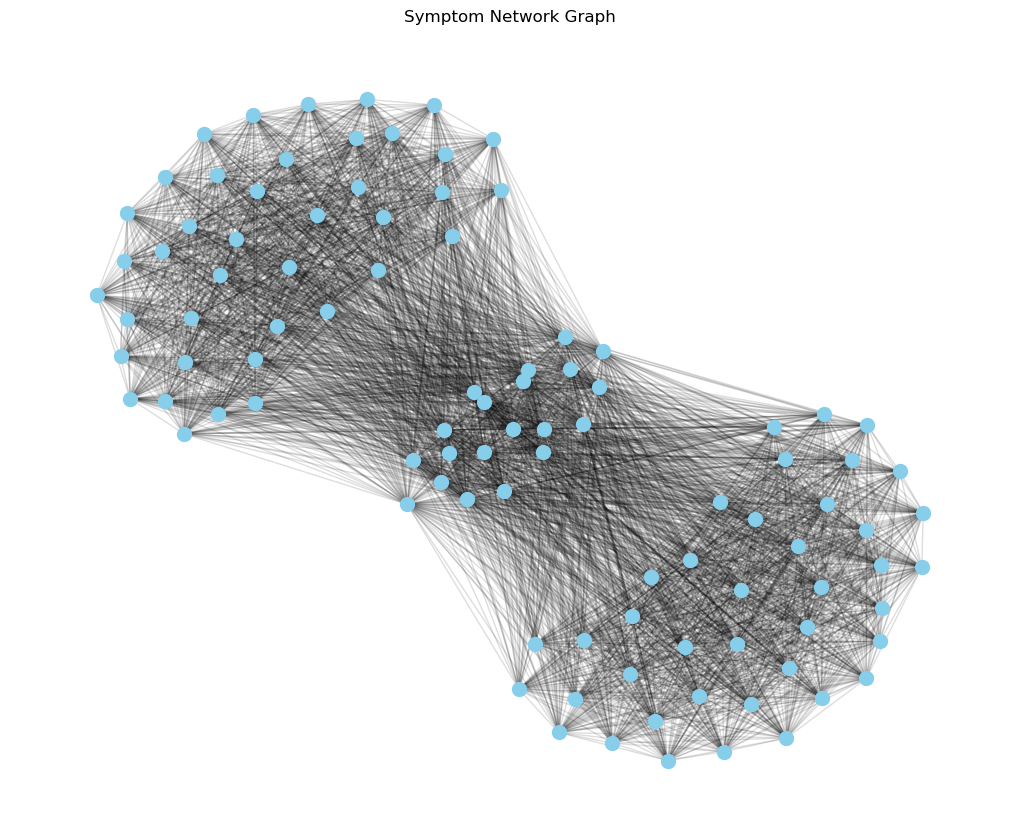

In [4]:
G = get_symptom_network(40, 20)
#G = nx.grid_2d_graph(20, 20, periodic=True)
print(len(G.nodes))

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42) 
nx.draw(G, pos, with_labels=False, node_color='skyblue', 
        node_size=100, edge_color='#00000022', font_size=10)
plt.title("Symptom Network Graph")
plt.show()

## Plotting

computed J: 0.0458


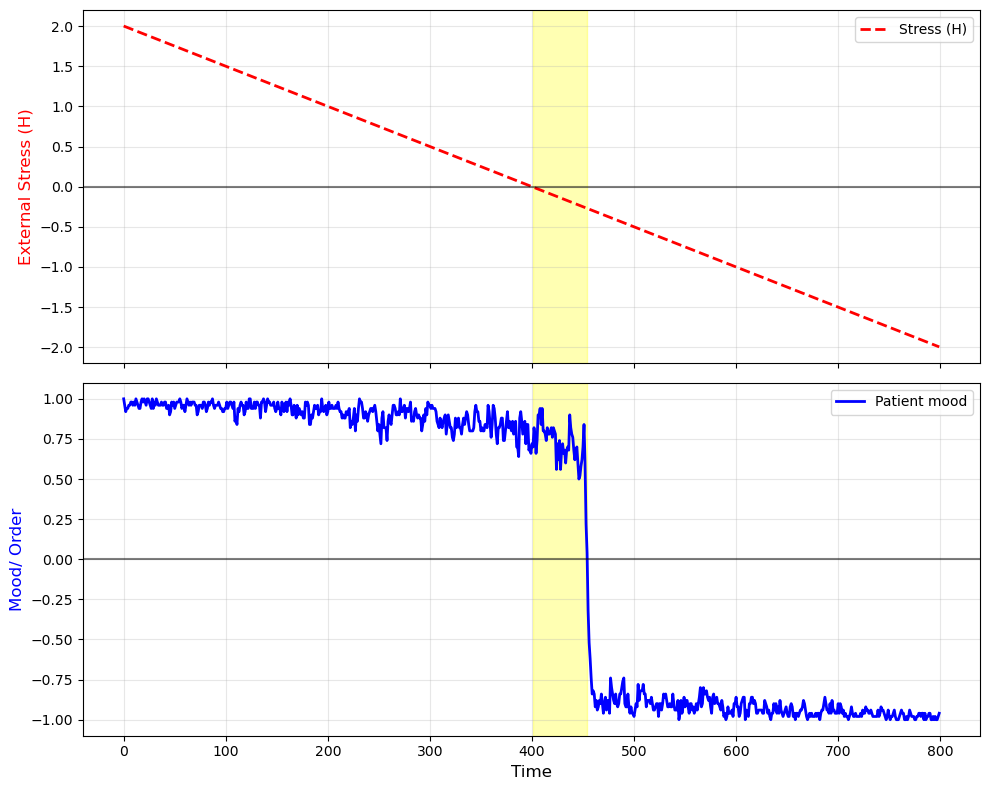

In [5]:
model = IsingSimulation(G, H=2.0, J=None, T=2.269, length=800, warmup=50)

model.run(delta_H=-0.005)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# top plot
ax1.plot(model.h_history, color='red', linestyle='--', linewidth=2, label="Stress (H)")
ax1.axhline(0, color='black', alpha=0.5)
ax1.set_ylabel("External Stress (H)", color='red', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')


# Where the outside stress is negative so unhealthy
bad_environment = model.h_history < 0

# Where the patients mood is still healthy, bellow 0
good_mood = model.order_history > 0

# The points where the stress is negative but the mood is still positive
metastable_indices = np.where(bad_environment & good_mood)[0]

# If there are any points where the above conditions are valid draw a yelow zone
if len(metastable_indices) > 0:
    start = metastable_indices[0]
    end = metastable_indices[-1]
    ax1.axvspan(start, end, color='yellow', alpha=0.3)

# bottom plot
ax2.plot(model.order_history, color='blue', linewidth=2, label="Patient mood")
ax2.axhline(0, color='black', alpha=0.5)
ax2.set_ylabel("Mood/ Order", color='blue', fontsize=12)
ax2.set_xlabel("Time", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

# Yellow zone of the bottom graph
if len(metastable_indices) > 0:
    ax2.axvspan(start, end, color='yellow', alpha=0.3)


plt.tight_layout()
plt.show()

computed J: 0.0458
Covariance matrices have not been calculated. Calculating now...


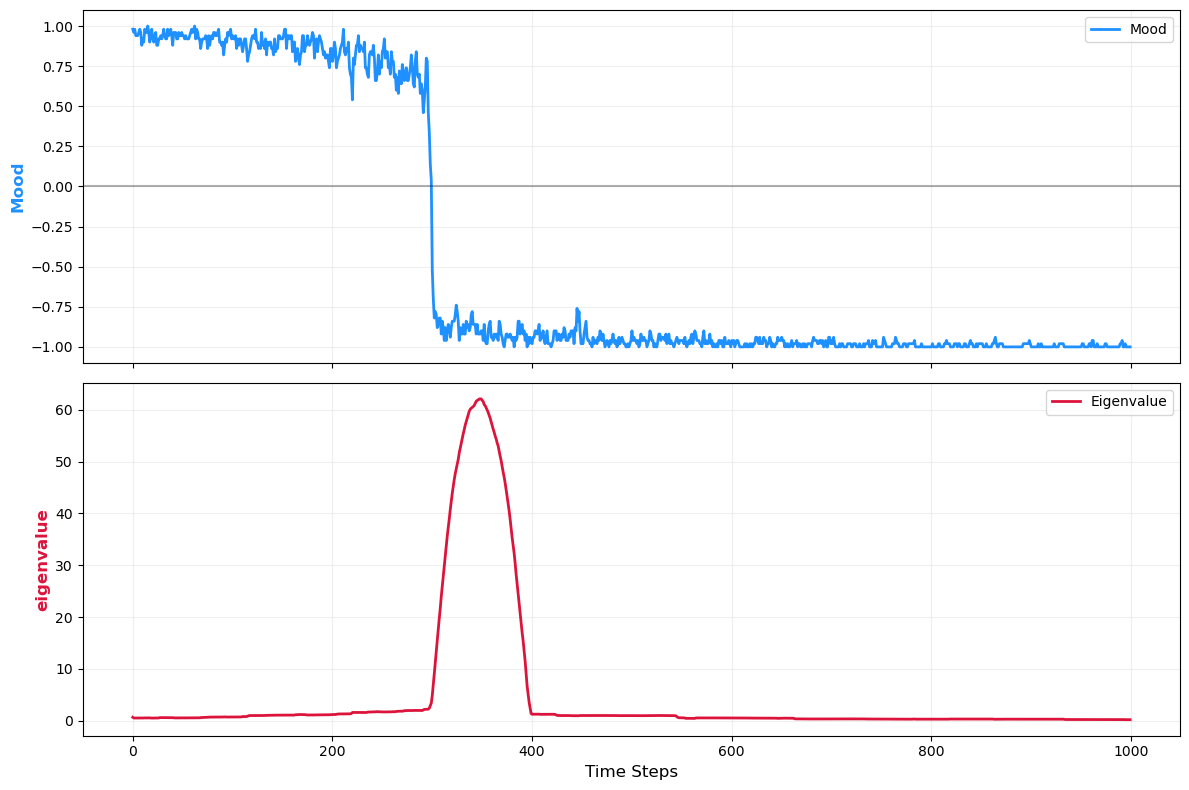

In [6]:
G = get_symptom_network(group_size=40, bridge_size=20)
model = IsingSimulation(G, H=1.5, J=None, T=2.269, length=1000, warmup=100)


model.run(delta_H=-0.006) 

# ews
warning_signal = model.get_early_warning_signal()


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)


ax1.plot(model.order_history, color='dodgerblue', linewidth=2, label="Mood")
ax1.set_ylabel("Mood", fontsize=12, fontweight='bold', color='dodgerblue')
ax1.axhline(0, color='black', alpha=0.3)
ax1.grid(True, alpha=0.2)
ax1.legend(loc='upper right')


ax2.plot(warning_signal, color='crimson', linewidth=2, label="Eigenvalue")
ax2.set_ylabel("eigenvalue", fontsize=12, fontweight='bold', color='crimson')
ax2.set_xlabel("Time Steps", fontsize=12)
ax2.grid(True, alpha=0.2)
ax2.legend(loc='upper right')


plt.tight_layout()
plt.show()

computed J: 0.0458
running
computing covariance and ews
Covariance matrices have not been calculated. Calculating now...


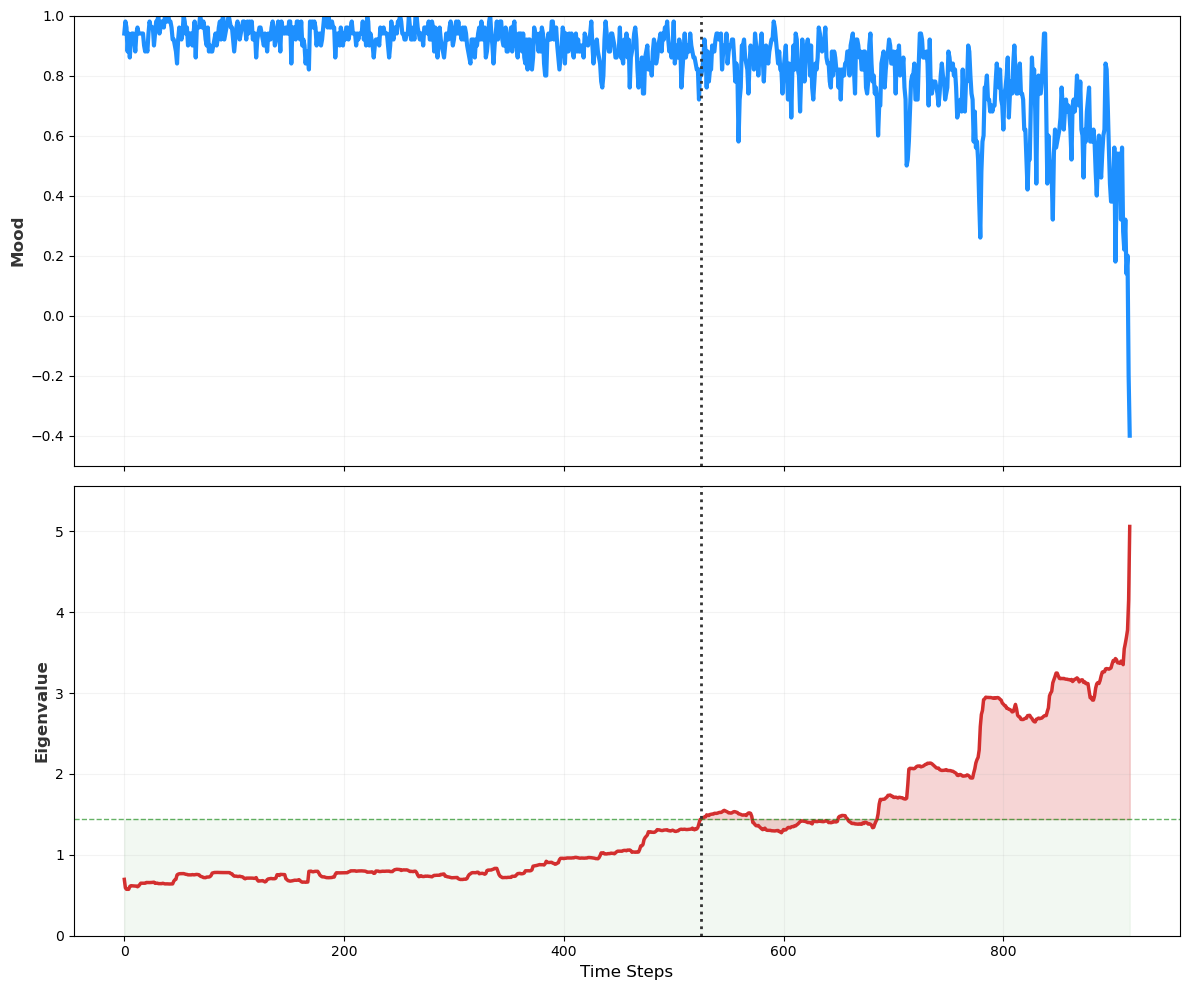

In [7]:
# the lower delta_H allows the patient to stay more time in the yellow zone, 
# which makes the covariance better at predicting fluctuations from the baseline
model = IsingSimulation(G, H=1.5, J=None, T=2.269, length=2000, warmup=100)

print("running")
model.run(delta_H=-0.002) 

# computing the covariance matrices and obtaining the time series with the early warning signal
print("computing covariance and ews")
warning_signal = model.get_early_warning_signal()

# finding a better way to describe the ews increase by only showing data up to the crash
crash_indices = np.where(model.order_history < -0.5)[0]
if len(crash_indices) > 0:
    cut_point = crash_indices[0] 


# slice data
time_axis = np.arange(cut_point)
mood_data = model.order_history[:cut_point]
signal_data = warning_signal[:cut_point]

# plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# mood
ax1.plot(time_axis, mood_data, color='dodgerblue', linewidth=3, label="Patients mood")
ax1.set_ylabel("Mood", fontsize=12, fontweight='bold', color='#333333')
ax1.set_ylim(-0.5, 1.0) # focus on positie mood values
ax1.grid(True, alpha=0.15)

# the signal
# calculate the baseline average from the first 500 steps and the standard deviation
baseline_mean = np.mean(signal_data[:500])
baseline_std = np.std(signal_data[:500])

# 4 sigma above the average
threshold = baseline_mean + (4 * baseline_std) 

# plot the eigenvalue
ax2.plot(time_axis, signal_data, color='#D32F2F', linewidth=2.5, label="Eigenvalue")

# below 4 sigma - the baseline area
ax2.fill_between(time_axis, 0, threshold, color='green', alpha=0.05, label="Normal Variance")
ax2.axhline(threshold, color='green', linestyle='--', linewidth=1, alpha=0.6)


# first time the signal crossed the threshold
danger_zone = np.where(signal_data > threshold)[0]

if len(danger_zone) > 0:
    
    # the first time 
    first_warning = danger_zone[0]
    
    # red fill above the 4 sigma threshold
    ax2.fill_between(time_axis[first_warning:], signal_data[first_warning:], threshold, 
                     color='#D32F2F', alpha=0.2)
    
    # veritcal line 
    ax2.axvline(first_warning, color='#333333', linestyle=':', linewidth=2)
    ax1.axvline(first_warning, color='#333333', linestyle=':', linewidth=2)
    

ax2.set_ylabel("Eigenvalue", fontsize=12, fontweight='bold', color='#333333')
ax2.set_xlabel("Time Steps", fontsize=12)
ax2.set_ylim(0, np.max(signal_data)*1.1)
ax2.grid(True, alpha=0.15)


plt.tight_layout()
plt.show()

## Animation

In [8]:
# create an animation showing the evolution of the network over time

def animate_model(model, filename, writer='ffmpeg',include_warmup=False):
    """
    Create an animation of the network evolution over time.
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.axis('off')
    node_list = list(model.network.nodes())
    states = model.history
    if include_warmup:
        states = np.vstack((model.warmup_states, model.history))
    length = len(states)
    pos = nx.spring_layout(model.network, seed=42)


    nx.draw_networkx_edges(model.network, pos, alpha=0.07, width=0.2, ax=ax, edge_color='grey')

    colors_init = []
    colors_init = ['red' if state == -1 else 'blue' for state in states[0]]
    nodes = nx.draw_networkx_nodes(model.network, pos,
                                   nodelist=node_list,
                                   node_color=colors_init,
                                   node_size=30,
                                   ax=ax)
    nodes.set_facecolors(np.array(colors_init))
    
    title = ax.text(0.5, 0.98, 't = 0',
                   fontsize=24, ha='center', va='top', color='black')
    
    fig.tight_layout()
    
    def update(frame):
        colors = ['red' if state == -1 else 'blue' for state in states[frame]]
        nodes.set_facecolors(np.array(colors))
        title.set_text(f't = {frame}')
        return nodes, title
    
    anim = animation.FuncAnimation(fig, update, frames=length,
                                  interval=50, blit=True)
    update_func = lambda _i, _n: progress_bar.update(1)
    with tqdm(total=length, desc='Saving video') as progress_bar:
        anim.save(filename, fps=5, dpi=150, bitrate=-1, writer=writer, 
                       progress_callback=update_func)
    print('Video saved successfully.')

computed J: 0.0458


Saving video: 100%|██████████| 200/200 [00:51<00:00,  3.90it/s]

Video saved successfully.


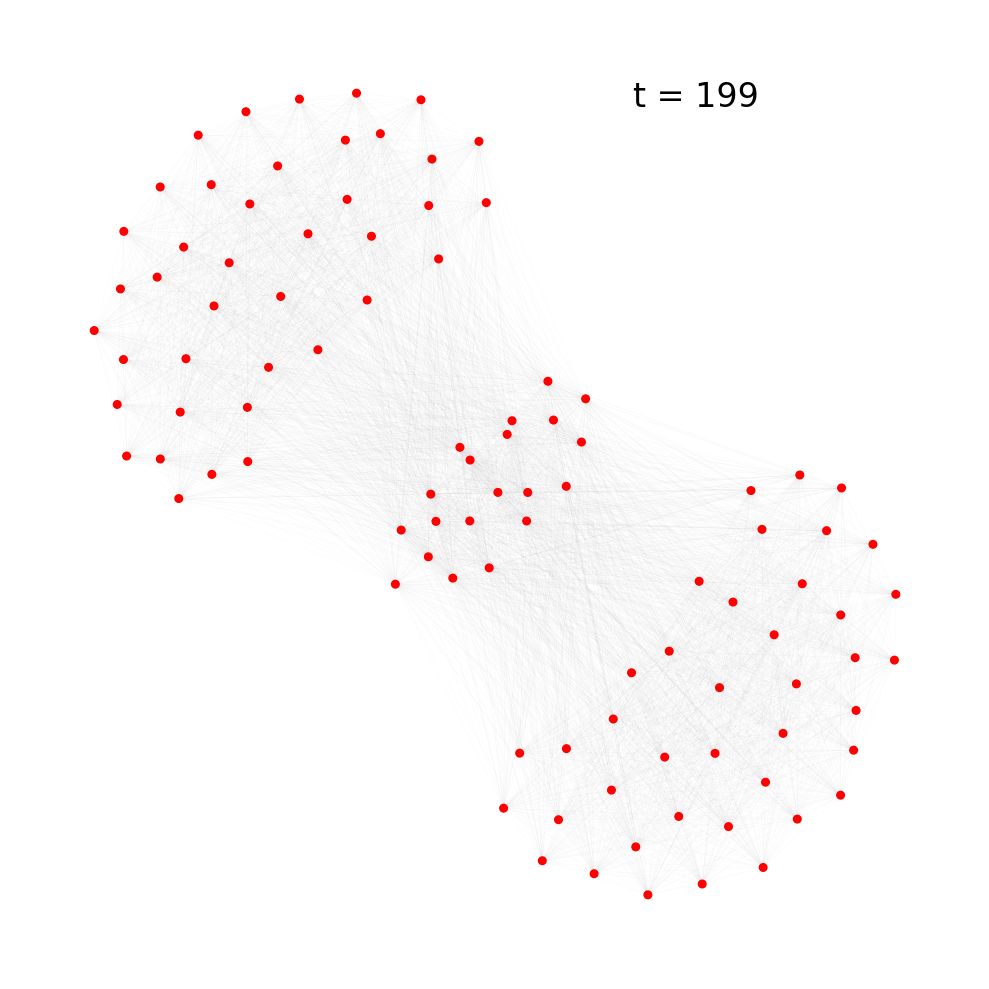

In [9]:
model = IsingSimulation(G, H=1.5, J=None, T=2.269, length=200, warmup=50)
model.run(delta_H=-0.03)
animate_model(model, filename='./simulation_crash.gif', writer='pillow')

## Model Validation

### Parameter sweep h

In [10]:
# iteratate over h and plot the order at the end of the simulation at each h
# TODO: @Julia

### Parameter sweep J

In [11]:
# iteratate over h and plot the order at the end of the simulation at each J
# TODO: @Julia

### Investigate stochastic effects

In [12]:
# run several iterations of the simulation at, near, and far from the CP using both high and low noise.
# plot results including mean and variance.
# TODO: @Kyle

### Hysteresis check

In [13]:
# use the delta_h parameter in the run function to slowly increase h past the critical point, then reduce back to starting value.
# plot the order parameter and h as a function of time.
# answers H5
# TODO: @Kyle

### Power Law analysis

In [14]:
# perform power law analysis, drawing inspiration from percolation theory
# TODO: @Julia

## Research Questions

In [15]:
# RQ1: To what extent can the largest eigenvalue of the symptom covariance matrix (σ1) predict critical transitions from a "healthy" to a "depressed" state within a simulated symptom network?
# slowly increase h past critical point. plot order, largest eigenvalue, and h as a function of time.
# answers H1/H3
# TODO: @Kyle

In [16]:
# H2: for the above simulation, plot dominant eigenvalue as percentage of total variance explained
# TODO: @Igor

In [17]:
# analyze the eigenvector corresponding to the largest eigenvalue
# H4
# TODO: @Julia